Silhouette Score: 0.616


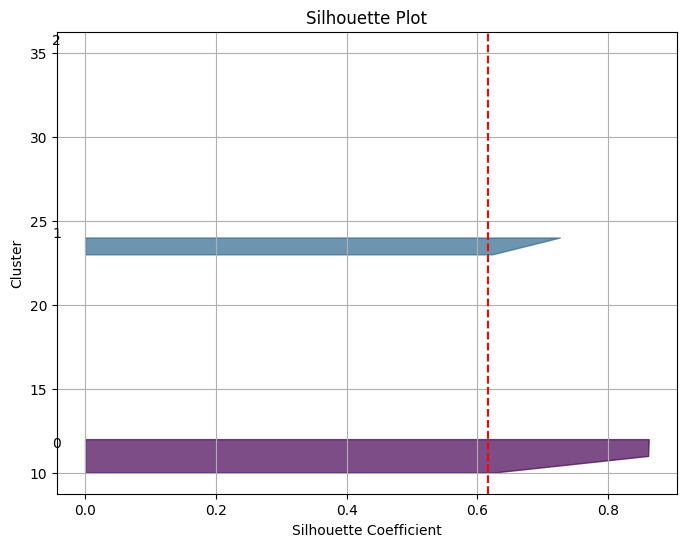


Cluster Summary:
         count         mean          min          max
Cluster                                              
0            3   320.034828     0.384473   950.569414
1            2  6557.602150  6065.261714  7049.942587
2            1  3454.200913  3454.200913  3454.200913
Clustered dataset saved as 'gicumbi_clustered.csv'.


In [1]:
# Phase 3: Clustering Model

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np

# 1. Load the cleaned dataset
df = pd.read_csv("gicumbi_cleaned_for_modeling.csv")

# 2. Select the feature(s) for clustering
features = ['wri_tropical_tree_cover_extent__ha']
X = df[features]

# 3. Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the clustering model on the dataset
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Evaluate the clustering using silhouette score
sil_score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {sil_score:.3f}")

# 6. Silhouette plot
sample_silhouette_values = silhouette_samples(X_scaled, df['Cluster'])

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[df['Cluster'] == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.viridis(float(i) / 3)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.set_title("Silhouette Plot")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.axvline(x=sil_score, color="red", linestyle="--")
plt.grid(True)
plt.show()

# 7. Summary of each cluster
summary = df.groupby('Cluster')['wri_tropical_tree_cover_extent__ha'].agg(['count', 'mean', 'min', 'max'])
print("\nCluster Summary:")
print(summary)

# 8. Save clustered dataset
df.to_csv("gicumbi_clustered.csv", index=False)
print("Clustered dataset saved as 'gicumbi_clustered.csv'.")
